In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

100%|██████████| 218M/218M [00:13<00:00, 16.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1


In [ ]:
import os
print("Contents of the downloaded dataset path:")
for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        print(f"  [DIR] {item}")
        # Optionally, list contents of the first level subdirectories too
        # for sub_item in os.listdir(item_path):
        #     print(f"    - {sub_item}")
    else:
        print(f"  [FILE] {item}")


Contents of the downloaded dataset path:
  [DIR] test_set
  [DIR] training_set


In [ ]:
import tensorflow as tf

# Check for GPU availability
gpu_available = tf.config.list_physical_devices('GPU')
if gpu_available:
    print(f"GPU is available: {gpu_available}")
    print("TensorFlow is using GPU.")
else:
    print("No GPU found. TensorFlow will use CPU.")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow is using GPU.


In [ ]:
import os

# 'path' points to the dataset root: /root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1
# From the directory listing, the structure is path/training_set/training_set/{cat,dog}

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

train_dir = os.path.join(path, 'training_set', 'training_set')
validation_dir = os.path.join(path, 'test_set', 'test_set') # Using 'test_set' as validation data

print(f"Training directory: {train_dir}")
print(f"Validation directory: {validation_dir}")

# Create image datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False # No need to shuffle validation data
)

# Normalize image data to [0, 1] and cache for performance
def preprocess(image, label):
    # Cast image to float32 before division
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Datasets prepared.")

Training directory: /root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1/training_set/training_set
Validation directory: /root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1/test_set/test_set
Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.
Datasets prepared.


In [ ]:
import os

print(f"Contents of {train_dir}:")
for item in os.listdir(train_dir):
    print(f"  - {item}")

print(f"\nContents of {validation_dir}:")
for item in os.listdir(validation_dir):
    print(f"  - {item}")


Contents of /root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1/training_set:
  - training_set

Contents of /root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1/test_set:
  - test_set


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load pre-trained ResNet50 model without the top classification layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the base model layers
base_model.trainable = False

# Create a new model on top of the pre-trained base
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1, activation='sigmoid') # Binary classification (cat/dog)
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
EPOCHS = 20 # You can adjust the number of epochs

print(f"Training started for {EPOCHS} epochs...")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)
print("Training finished.")

Training started for 20 epochs...
Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 55s 156ms/step - accuracy: 0.5824 - loss: 0.6871 - val_accuracy: 0.6021 - val_loss: 0.6826
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 25s 101ms/step - accuracy: 0.6160 - loss: 0.6785 - val_accuracy: 0.6100 - val_loss: 0.6765
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.6209 - loss: 0.6722 - val_accuracy: 0.6139 - val_loss: 0.6719
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 28s 114ms/step - accuracy: 0.6200 - loss: 0.6674 - val_accuracy: 0.6199 - val_loss: 0.6685
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.6215 - loss: 0.6637 - val_accuracy: 0.6199 - val_loss: 0.6659
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 27s 109ms/step - accuracy: 0.6225 - loss: 0.6608 - val_accuracy: 0.6209 - val_loss: 0.6639
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.6237 - loss: 0.6585 - val_accuracy: 0.6199 - val_loss: 0.6623
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms

In [ ]:
import pandas as pd

# Convert the history object to a DataFrame for easier analysis
hist_df = pd.DataFrame(history.history)

print("Training Summary:")
print(hist_df.tail(1)) # Display last epoch's metrics

# Evaluate the model on the validation set
loss, accuracy = model.evaluate(val_ds)
print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

Training Summary:
    accuracy      loss  val_accuracy  val_loss
19  0.632605  0.645631      0.626298  0.653634
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.6263 - loss: 0.6536

Validation Loss: 0.6536
Validation Accuracy: 0.6263


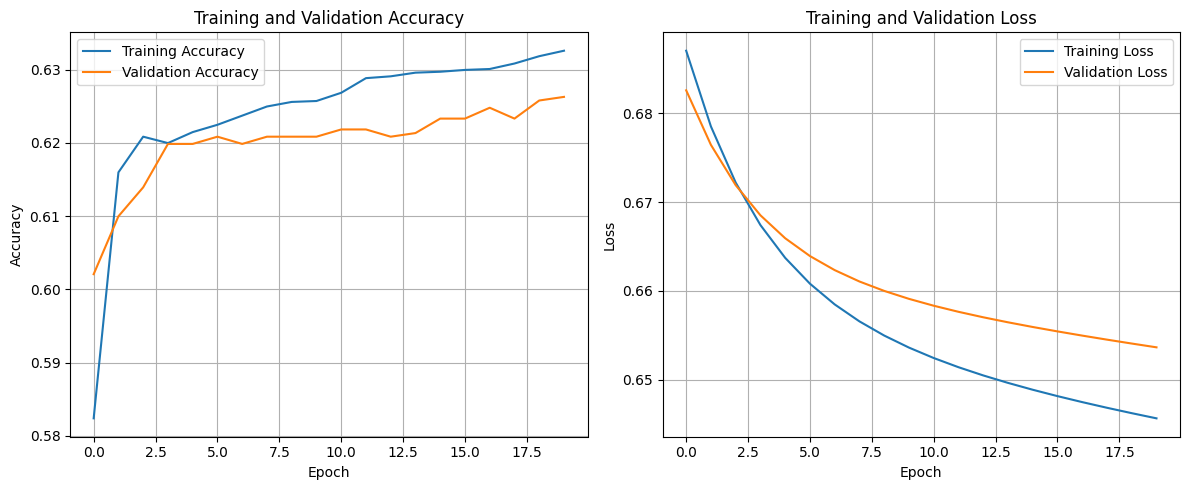

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()